In [1]:
from astropy.io import fits
import numpy as np
from astropy.table import Table
import pandas as pd
import glob
from astropy.table import vstack
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages
import os

In [2]:
df = pd.read_csv("../Class_wise_v4/Halpha_emitter_wise_group4.csv")
len(df)

301

In [3]:
df['W1-W2'] = df['W1mag'] - df['W2mag']
df['J-H'] = df['Jmag'] - df['Hmag']
df['H-W2'] = df['Hmag'] - df['W2mag']
df['r-i'] = df['rImag'] - df['imag']
df['r-Ha'] = df['rImag'] - df['Hamag']


In [4]:
# Condiciones corregidas (cada una entre paréntesis)
df_yso = df[(df['W1-W2'] <= 0.865) & (df['J-H'] >= 0.75) & (df['H-W2'] <= 2.7)]

In [5]:
len(df_yso )

234

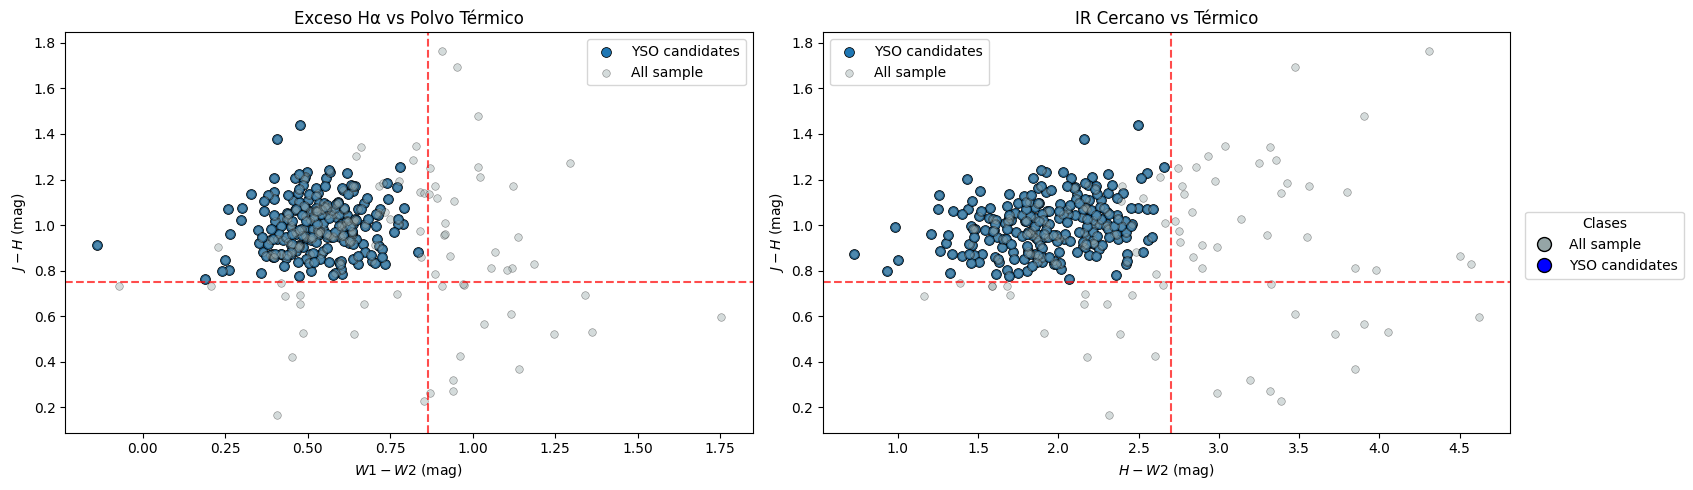

In [6]:
# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Diagrama 1: J - H vs W1-W2 ---
sns.scatterplot(
    x="W1-W2", y="J-H", 
    data=df_yso, ax=axes[0], s=50, edgecolor='black',
    label="YSO candidates"  # Usar label para la leyenda
)

sns.scatterplot(
    x="W1-W2", y="J-H", 
    data=df, ax=axes[0], s=30, edgecolor='black', 
    color='#95a5a6', alpha=0.4,  # Parámetros separados correctamente
    label="All sample"  # Usar label para la leyenda
)

axes[0].axvline(0.865, color='red', linestyle='--', alpha=0.7)
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel(r"$W1 - W2$ (mag)")
axes[0].set_ylabel(r"$J - H$ (mag)")
axes[0].set_title("Exceso Hα vs Polvo Térmico")

# --- Diagrama 2: J-H vs H-W2 ---
sns.scatterplot(
    x="H-W2", y="J-H", 
    data=df_yso, ax=axes[1], s=50, edgecolor='black',
    label="YSO candidates"  # Usar label para la leyenda
)

sns.scatterplot(
    x="H-W2", y="J-H", 
    data=df, ax=axes[1], s=30, edgecolor='black', 
    color='#95a5a6', alpha=0.4,  # Parámetros separados correctamente
    label="All sample"  # Usar label para la leyenda
)

axes[1].axvline(2.7, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(0.75, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel(r"$H - W2$ (mag)")  # Corregido el nombre del eje X
axes[1].set_ylabel(r"$J - H$ (mag)")
axes[1].set_title("IR Cercano vs Térmico")

# Crear leyenda única manualmente
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markersize=10, markeredgecolor='black', markerfacecolor='#95a5a6', label='All sample'),
    Line2D([0], [0], marker='o', color='w', markersize=10, markeredgecolor='black', markerfacecolor='blue', label='YSO candidates')
]

fig.legend(handles=legend_elements, title="Clases",
           bbox_to_anchor=(0.85, 0.5), loc='center left',
           borderaxespad=0.)

# Ajustar layout para dejar espacio a la leyenda
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# PNe slection

In [7]:
# Se generan tres tablas donde cada una cumple un criterio-- estos criterios son objetos que Pueden ser PN candidates

df_W1W2 = df[(df['W1-W2'] >= 0.865)]
df_JH = df[(df['J-H'] <= 0.75)]
df_HW2 = df[(df['H-W2'] >= 2.7)]

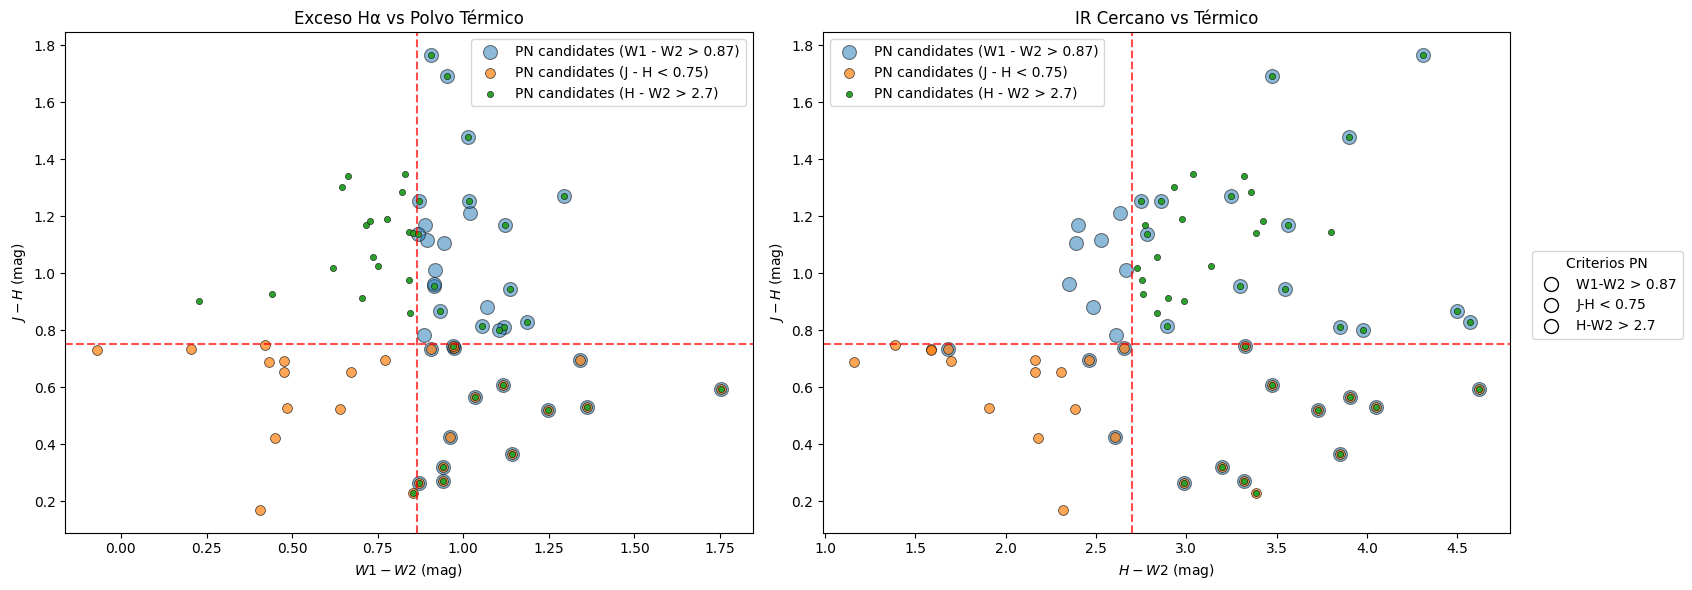

In [8]:
# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Diagrama 1: J - H vs W1-W2 ---
sns.scatterplot(
    x="W1-W2", y="J-H", 
    data=df_W1W2, ax=axes[0], s=100, edgecolor='black', alpha=0.5,
    label="PN candidates (W1 - W2 > 0.87)"
)

sns.scatterplot(
    x="W1-W2", y="J-H", 
    data=df_JH, ax=axes[0], s=50, edgecolor='black', alpha=0.7,
    label="PN candidates (J - H < 0.75)"
)

sns.scatterplot(
    x="W1-W2", y="J-H", 
    data=df_HW2, ax=axes[0], s=20, edgecolor='black', 
    label="PN candidates (H - W2 > 2.7)"
)

axes[0].axvline(0.865, color='red', linestyle='--', alpha=0.7)
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel(r"$W1 - W2$ (mag)")
axes[0].set_ylabel(r"$J - H$ (mag)")
axes[0].set_title("Exceso Hα vs Polvo Térmico")

# --- Diagrama 2: J-H vs H-W2 ---
# Corregir "H2-W2" a "H-W2" y usar axes[1]
sns.scatterplot(
    x="H-W2", y="J-H", 
    data=df_W1W2, ax=axes[1], s=100, edgecolor='black', alpha=0.5,
    label="PN candidates (W1 - W2 > 0.87)"
)

sns.scatterplot(
    x="H-W2", y="J-H", 
    data=df_JH, ax=axes[1], s=50, edgecolor='black', alpha=0.7,
    label="PN candidates (J - H < 0.75)"
)

sns.scatterplot(
    x="H-W2", y="J-H", 
    data=df_HW2, ax=axes[1], s=20, edgecolor='black', 
    label="PN candidates (H - W2 > 2.7)"
)

axes[1].axvline(2.7, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(0.75, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel(r"$H - W2$ (mag)")
axes[1].set_ylabel(r"$J - H$ (mag)")
axes[1].set_title("IR Cercano vs Térmico")

# Leyenda actualizada con las 3 categorías
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='W1-W2 > 0.87'),
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='J-H < 0.75'),
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='H-W2 > 2.7')
]

fig.legend(handles=legend_elements, title="Criterios PN",
           bbox_to_anchor=(0.85, 0.5), loc='center left')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Ortra forma

Se me ocurrio una idea puedo seleccionar -- ERA OBVIO!!

In [9]:
df_d1r1 = df[(df['J-H'] <= 0.85) & (df['W1-W2'] <= 0.75)]
df_d1r2 = df[(df['J-H'] <= 0.85) & (df['W1-W2'] >= 0.75)]
df_d1r3 = df[(df['J-H'] >= 0.85) & (df['W1-W2'] >= 0.75)]

In [10]:
df_d1_final = pd.concat([df_d1r1, df_d1r2, df_d1r3], axis=0)
df_d1_final =  df_d1_final.reset_index(drop=True)
len(df_d1_final)

91

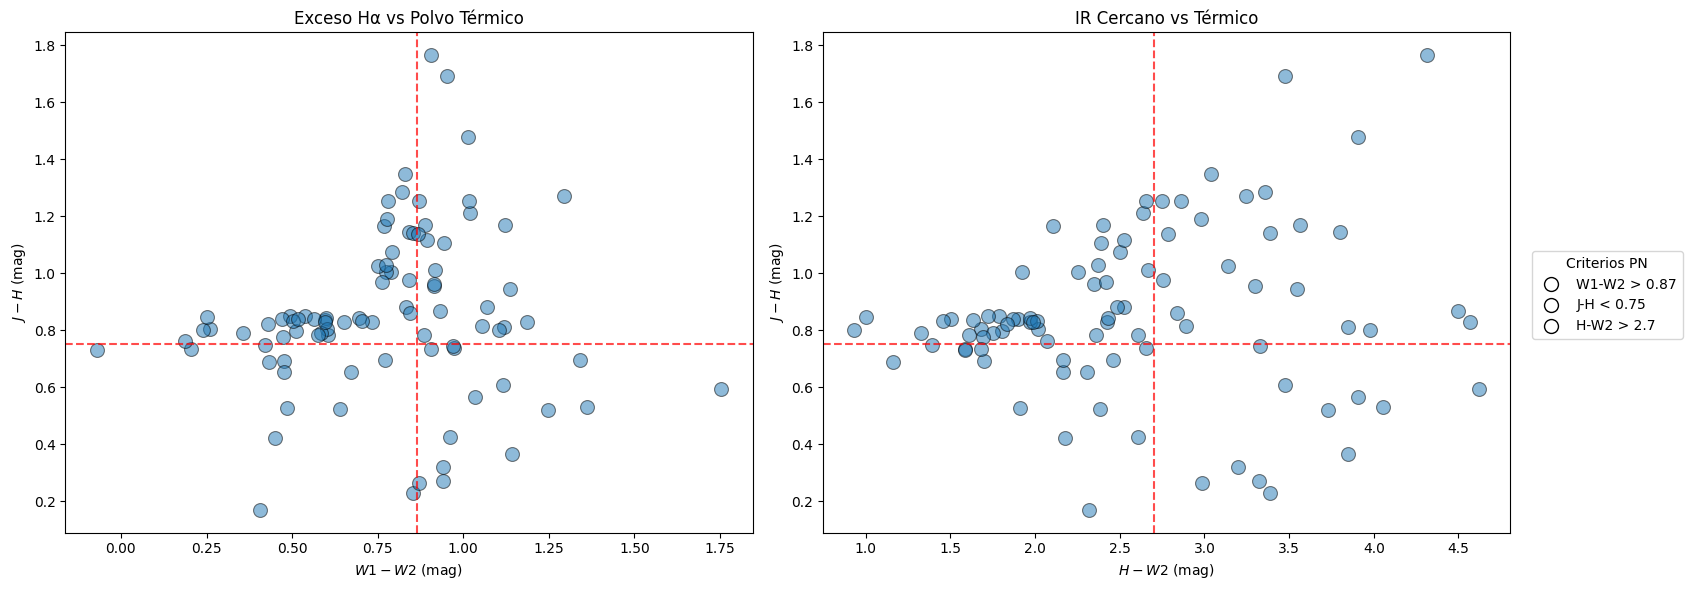

In [11]:
# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Diagrama 1: J - H vs W1-W2 ---
sns.scatterplot(
    x="W1-W2", y="J-H", 
    data=df_d1_final, ax=axes[0], s=100, edgecolor='black', alpha=0.5
)


axes[0].axvline(0.865, color='red', linestyle='--', alpha=0.7)
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel(r"$W1 - W2$ (mag)")
axes[0].set_ylabel(r"$J - H$ (mag)")
axes[0].set_title("Exceso Hα vs Polvo Térmico")

# --- Diagrama 2: J-H vs H-W2 ---
# Corregir "H2-W2" a "H-W2" y usar axes[1]
sns.scatterplot(
    x="H-W2", y="J-H", 
    data=df_d1_final, ax=axes[1], s=100, edgecolor='black', alpha=0.5
)


axes[1].axvline(2.7, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(0.75, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel(r"$H - W2$ (mag)")
axes[1].set_ylabel(r"$J - H$ (mag)")
axes[1].set_title("IR Cercano vs Térmico")

# Leyenda actualizada con las 3 categorías
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='W1-W2 > 0.87'),
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='J-H < 0.75'),
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='H-W2 > 2.7')
]

fig.legend(handles=legend_elements, title="Criterios PN",
           bbox_to_anchor=(0.85, 0.5), loc='center left')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Ahora el otro digrama, pero trabajemos con esta última tabla

In [12]:
df_d2r1 = df_d1_final[(df_d1_final['J-H'] <= 0.85) & (df_d1_final['H-W2'] <= 2.7)]
df_d2r2 = df_d1_final[(df_d1_final['J-H'] <= 0.85) & (df_d1_final['H-W2'] >= 2.7)]
df_d2r3 = df_d1_final[(df_d1_final['J-H'] >= 0.85) & (df_d1_final['H-W2'] >= 2.7)]

In [13]:
df_d2_final = pd.concat([df_d2r1, df_d2r2, df_d2r3], axis=0)
df_d2_final =  df_d2_final.reset_index(drop=True)
len(df_d2_final)

76

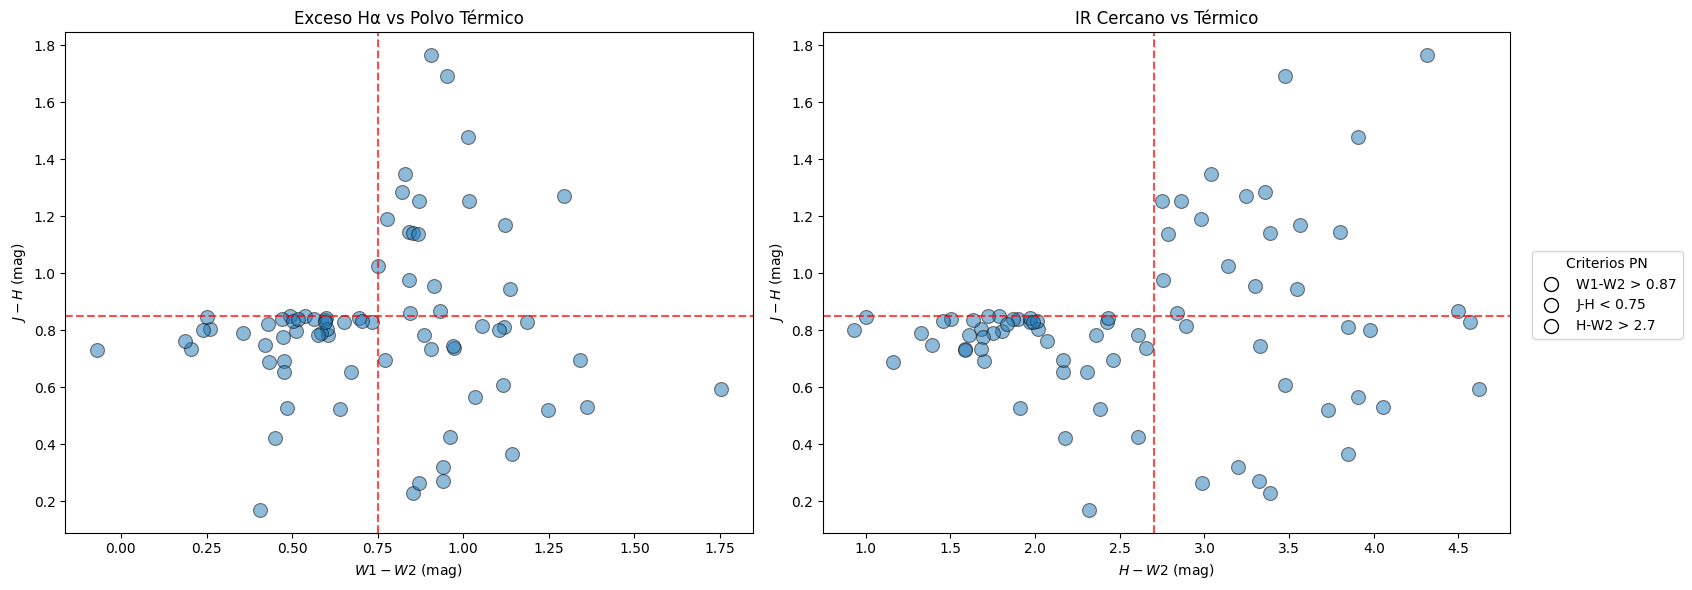

In [15]:
# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Diagrama 1: J - H vs W1-W2 ---
sns.scatterplot(
    x="W1-W2", y="J-H", 
    data=df_d2_final, ax=axes[0], s=100, edgecolor='black', alpha=0.5
)


axes[0].axvline(0.75, color='red', linestyle='--', alpha=0.7)
axes[0].axhline(0.85, color='red', linestyle='--', alpha=0.7)
axes[0].set_xlabel(r"$W1 - W2$ (mag)")
axes[0].set_ylabel(r"$J - H$ (mag)")
axes[0].set_title("Exceso Hα vs Polvo Térmico")

# --- Diagrama 2: J-H vs H-W2 ---
# Corregir "H2-W2" a "H-W2" y usar axes[1]
sns.scatterplot(
    x="H-W2", y="J-H", 
    data=df_d2_final, ax=axes[1], s=100, edgecolor='black', alpha=0.5
)


axes[1].axvline(2.7, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(0.85, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel(r"$H - W2$ (mag)")
axes[1].set_ylabel(r"$J - H$ (mag)")
axes[1].set_title("IR Cercano vs Térmico")

# Leyenda actualizada con las 3 categorías
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='W1-W2 > 0.87'),
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='J-H < 0.75'),
    Line2D([0], [0], marker='o', color='w', markersize=10, 
             markeredgecolor='black', label='H-W2 > 2.7')
]

fig.legend(handles=legend_elements, title="Criterios PN",
           bbox_to_anchor=(0.85, 0.5), loc='center left')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [16]:
# Guardar resultados
directorio_salida = os.path.abspath("../Results_PNe_final")
os.makedirs(directorio_salida, exist_ok=True)
df_d2_final.to_csv(f"{directorio_salida}/PNe_candidates.csv", index=False)

In [17]:
df_d2_final

,Name,RAJ2000,DEJ2000,GLON,GLAT,SourceID,ePos,Class,pStar,pGalaxy,...,PC2,PC3,PC4,PC5,Label,W1-W2,J-H,H-W2,r-i,r-Ha
0,J194751.91+311818.2,296.966304,31.305043,66.858708,2.957180,572370-1-13529,0.056,99.0,0.05,0.95,...,5.169250,2.419987,2.850275,4.112815,4,0.406,0.169,2.319,0.30,1.64
1,J200052.92+342822.1,300.220485,34.472813,70.984775,2.244480,475174-4-11414,0.039,99.0,0.95,0.05,...,5.381966,2.487334,2.667249,4.080688,4,0.641,0.524,2.385,0.64,1.82
2,J200728.66+361829.4,301.869397,36.308153,73.255690,2.085373,940283-1-14507,0.024,-1.0,1.00,0.00,...,4.238023,2.528971,3.006889,5.411089,4,0.261,0.805,1.682,0.82,0.97
3,J202007.87+400508.2,305.032780,40.085611,77.780051,2.099715,531505-1-2730,0.042,99.0,1.00,0.00,...,4.551014,3.040881,3.141006,5.012918,4,0.206,0.735,1.585,1.23,1.53
4,J204733.97+413136.6,311.891533,41.526844,82.033377,-1.205794,367757-2-1738,0.064,99.0,0.05,0.95,...,4.814380,2.655554,2.972438,4.735016,4,0.596,0.836,1.633,1.25,1.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,J043236.68+424121.0,68.152842,42.689172,160.195103,-3.629631,635595-3-744,0.037,-1.0,1.00,0.00,...,5.191644,3.423185,2.477075,5.923687,4,0.870,1.252,2.748,1.11,1.43
72,J025105.22+603324.8,42.771749,60.556884,137.123611,1.024846,948818-2-2934,0.032,99.0,1.00,0.00,...,4.732788,2.870601,2.524191,5.535629,4,0.750,1.027,3.139,0.96,1.36
73,J040054.32+554820.9,60.226352,55.805814,147.373884,2.200333,538302-4-5208,0.018,99.0,0.95,0.05,...,5.322906,3.128142,2.447635,5.991773,4,1.015,1.478,3.904,0.66,1.35
74,J213125.08+491835.5,322.854489,49.309868,92.954582,-1.557863,756055-4-3272,0.025,-1.0,1.00,0.00,...,5.505894,3.187263,2.457786,5.899453,4,0.868,1.138,2.783,0.98,1.33


Make the optical diagram

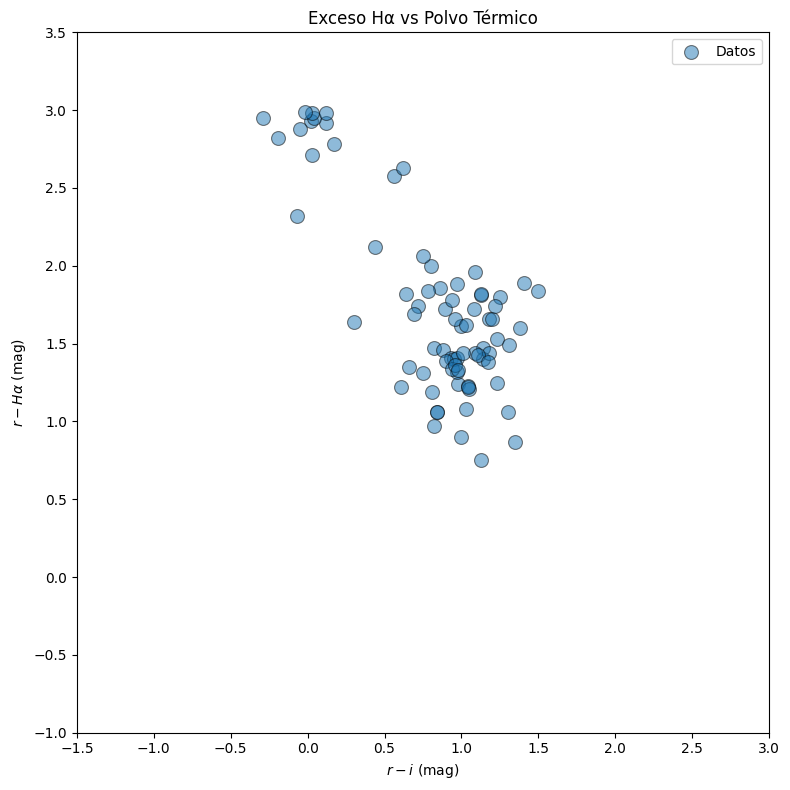

In [18]:
# Crear figura con un solo eje (no es necesario usar subplots si solo es uno)
fig, ax = plt.subplots(figsize=(8, 8))

# --- Scatterplot ---
sns.scatterplot(
    x="r-i", y="r-Ha", 
    data=df_d2_final, ax=ax, s=100, edgecolor='black', alpha=0.5,
    label="Datos"  # Añadir etiqueta para la leyenda
)

# Etiquetas y título
ax.set_xlabel(r"$r - i$ (mag)")  # Corregido: variable en eje X es "r-i"
ax.set_ylabel(r"$r - H\alpha$ (mag)")  # Corregido: variable en eje Y es "r-Ha"
ax.set_title("Exceso Hα vs Polvo Térmico")
ax.set_xlim(-1.5, 3.0) 
ax.set_ylim(-1., 3.5) 

# Leyenda
ax.legend()

plt.tight_layout()
plt.show()

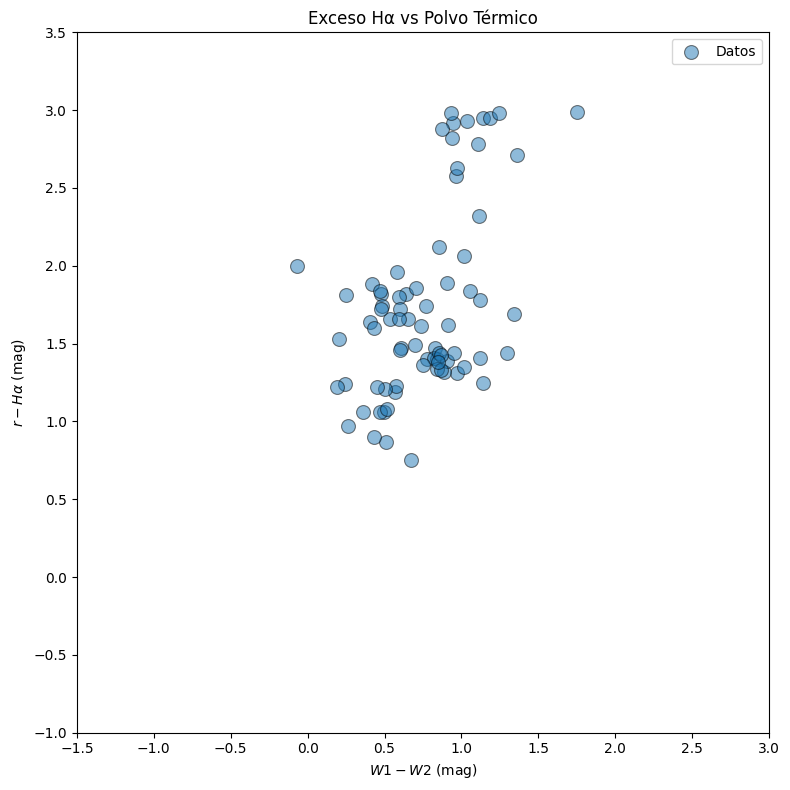

In [19]:
# Crear figura con un solo eje (no es necesario usar subplots si solo es uno)
fig, ax = plt.subplots(figsize=(8, 8))

# --- Scatterplot ---
sns.scatterplot(
    x="W1-W2", y="r-Ha", 
    data=df_d2_final, ax=ax, s=100, edgecolor='black', alpha=0.5,
    label="Datos"  # Añadir etiqueta para la leyenda
)

# Etiquetas y título
ax.set_xlabel(r"$W1-W2$ (mag)")  # Corregido: variable en eje X es "r-i"
ax.set_ylabel(r"$r - H\alpha$ (mag)")  # Corregido: variable en eje Y es "r-Ha"
ax.set_title("Exceso Hα vs Polvo Térmico")
ax.set_xlim(-1.5, 3.0) 
ax.set_ylim(-1., 3.5) 

# Leyenda
ax.legend()

plt.tight_layout()
plt.show()

## Droping SIMBAD sources

In [20]:
df_simbad = pd.read_csv('../Results_PNe_final/PNe_candidates-simbad2arcs.csv')       # Ajusta el SIMBAD
df_hash = pd.read_csv('../Results_PNe_final/PNe_candidates-HASH2arcs.csv')           # Ajusta el HASH
print("Simbad:", len(df_simbad))
print("HASH:", len(df_hash))

Simbad: 57
HASH: 16


In [21]:
print(df_simbad.columns.tolist())

['Name', 'RAJ2000', 'DEJ2000', 'GLON', 'GLAT', 'SourceID', 'ePos', 'Class', 'pStar', 'pGalaxy', 'pNoise', 'imag', 'e_imag', 'imagAB', 'Elli', 'Classi', 'Deblendi', 'Saturatedi', 'Vignettedi', 'Traili', 'Truncatedi', 'BadPixi', 'MJDi', 'Seeingi', 'DetIDi', 'offRAi', 'offDEi', 'Hamag', 'e_Hamag', 'HamagAB', 'EllHa', 'ClassHa', 'DeblendHa', 'SaturatedHa', 'VignettedHa', 'TrailHa', 'TruncatedHa', 'BadPixHa', 'MJDHa', 'SeeingHa', 'DetIDHa', 'offRAHa', 'offDEHa', 'rImag', 'e_rImag', 'rImagAB', 'EllrI', 'ClassrI', 'DeblendrI', 'SaturatedrI', 'VignettedrI', 'TrailrI', 'TruncatedrI', 'BadPixrI', 'MJDrI', 'SeeingrI', 'DetIDrI', 'rUmag', 'e_rUmag', 'rUmagAB', 'EllrU', 'ClassrU', 'DeblendrU', 'SaturatedrU', 'VignettedrU', 'TrailrU', 'TruncatedrU', 'BadPixrU', 'MJDrU', 'SeeingrU', 'DetIDrU', 'offRArU', 'offDErU', 'gmag', 'e_gmag', 'gmagAB', 'Ellg', 'Classg', 'Deblendg', 'Saturatedg', 'Vignettedg', 'Trailg', 'Truncatedg', 'BadPixg', 'maskg', 'MJDg', 'Seeingg', 'DetIDg', 'offRAg', 'offDEg', 'Umag', '

In [22]:
# Realizar el merge con SIMBAD para obtener 'main_type' y 'main_id'
df_final = df_d2_final.merge(
    df_simbad[['RAJ2000', 'DEJ2000', 'main_id', 'main_type']],  # Columnas a incluir desde SIMBAD
    on=['RAJ2000', 'DEJ2000'],  # Clave de unión (coordenadas)
    how='left',
    suffixes=('', '_simbad')
)

# Renombrar columnas de SIMBAD
df_final.rename(columns={
    'main_type': 'Clasificacion_SIMBAD',
    'main_id': 'ID_SIMBAD'
}, inplace=True)


In [23]:
## Rellenar 'N' donde no hay coincidencia
df_final['Clasificacion_SIMBAD'].fillna('N', inplace=True)
df_final['ID_SIMBAD'].fillna('N', inplace=True)  # Opcional: Si prefieres 'N' en lugar de NaN para IDs

/tmp/ipykernel_2435218/4205362800.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['Clasificacion_SIMBAD'].fillna('N', inplace=True)
/tmp/ipykernel_2435218/4205362800.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [24]:
df_final.columns.tolist()

['Name',
 'RAJ2000',
 'DEJ2000',
 'GLON',
 'GLAT',
 'SourceID',
 'ePos',
 'Class',
 'pStar',
 'pGalaxy',
 'pNoise',
 'imag',
 'e_imag',
 'imagAB',
 'Elli',
 'Classi',
 'Deblendi',
 'Saturatedi',
 'Vignettedi',
 'Traili',
 'Truncatedi',
 'BadPixi',
 'MJDi',
 'Seeingi',
 'DetIDi',
 'offRAi',
 'offDEi',
 'Hamag',
 'e_Hamag',
 'HamagAB',
 'EllHa',
 'ClassHa',
 'DeblendHa',
 'SaturatedHa',
 'VignettedHa',
 'TrailHa',
 'TruncatedHa',
 'BadPixHa',
 'MJDHa',
 'SeeingHa',
 'DetIDHa',
 'offRAHa',
 'offDEHa',
 'rImag',
 'e_rImag',
 'rImagAB',
 'EllrI',
 'ClassrI',
 'DeblendrI',
 'SaturatedrI',
 'VignettedrI',
 'TrailrI',
 'TruncatedrI',
 'BadPixrI',
 'MJDrI',
 'SeeingrI',
 'DetIDrI',
 'rUmag',
 'e_rUmag',
 'rUmagAB',
 'EllrU',
 'ClassrU',
 'DeblendrU',
 'SaturatedrU',
 'VignettedrU',
 'TrailrU',
 'TruncatedrU',
 'BadPixrU',
 'MJDrU',
 'SeeingrU',
 'DetIDrU',
 'offRArU',
 'offDErU',
 'gmag',
 'e_gmag',
 'gmagAB',
 'Ellg',
 'Classg',
 'Deblendg',
 'Saturatedg',
 'Vignettedg',
 'Trailg',
 'Truncated

In [25]:
# Realizar el merge con HASH usando las columnas de coordenadas correctas
df_final = df_final.merge(
    df_hash[['RAJ2000_1', 'DEJ2000', 'Name_2', 'PNstat']],  # Columnas de HASH
    left_on=['RAJ2000', 'DEJ2000'],      # Columnas en df_final
    right_on=['RAJ2000_1', 'DEJ2000'],  # Columnas en df_hash
    how='left',
    suffixes=('', '_hash')
)

In [26]:
# Eliminar columnas redundantes de coordenadas (opcional)
df_final.drop(['RAJ2000_1'], axis=1, inplace=True)

# Rellenar 'N' donde no hay coincidencia en HASH
df_final['Name_2'].fillna('N', inplace=True)
df_final['PNstat'].fillna('N', inplace=True)

/tmp/ipykernel_2435218/1883822461.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['Name_2'].fillna('N', inplace=True)
/tmp/ipykernel_2435218/1883822461.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [27]:
df_final.columns.tolist()

['Name',
 'RAJ2000',
 'DEJ2000',
 'GLON',
 'GLAT',
 'SourceID',
 'ePos',
 'Class',
 'pStar',
 'pGalaxy',
 'pNoise',
 'imag',
 'e_imag',
 'imagAB',
 'Elli',
 'Classi',
 'Deblendi',
 'Saturatedi',
 'Vignettedi',
 'Traili',
 'Truncatedi',
 'BadPixi',
 'MJDi',
 'Seeingi',
 'DetIDi',
 'offRAi',
 'offDEi',
 'Hamag',
 'e_Hamag',
 'HamagAB',
 'EllHa',
 'ClassHa',
 'DeblendHa',
 'SaturatedHa',
 'VignettedHa',
 'TrailHa',
 'TruncatedHa',
 'BadPixHa',
 'MJDHa',
 'SeeingHa',
 'DetIDHa',
 'offRAHa',
 'offDEHa',
 'rImag',
 'e_rImag',
 'rImagAB',
 'EllrI',
 'ClassrI',
 'DeblendrI',
 'SaturatedrI',
 'VignettedrI',
 'TrailrI',
 'TruncatedrI',
 'BadPixrI',
 'MJDrI',
 'SeeingrI',
 'DetIDrI',
 'rUmag',
 'e_rUmag',
 'rUmagAB',
 'EllrU',
 'ClassrU',
 'DeblendrU',
 'SaturatedrU',
 'VignettedrU',
 'TrailrU',
 'TruncatedrU',
 'BadPixrU',
 'MJDrU',
 'SeeingrU',
 'DetIDrU',
 'offRArU',
 'offDErU',
 'gmag',
 'e_gmag',
 'gmagAB',
 'Ellg',
 'Classg',
 'Deblendg',
 'Saturatedg',
 'Vignettedg',
 'Trailg',
 'Truncated

In [28]:
imp_inf = df_final[["RAJ2000", "DEJ2000", "Clasificacion_SIMBAD", "ID_SIMBAD", "PNstat", "Name_2"]]
imp_inf

,RAJ2000,DEJ2000,Clasificacion_SIMBAD,ID_SIMBAD,PNstat,Name_2
0,296.966304,31.305043,PlanetaryNeb,IRAS 19459+3110,T,IPHASX J194751.9+311818
1,300.220485,34.472813,PlanetaryNeb,IRAS 19589+3419,P,PM 1-316
2,301.869397,36.308153,EmLine*,Gaia DR2 2059218737172643072,N,N
3,305.032780,40.085611,N,N,N,N
4,311.891533,41.526844,EmLine*,2MASS J20473397+4131367,N,N
...,...,...,...,...,...,...
71,68.152842,42.689172,N,N,N,N
72,42.771749,60.556884,YSO_Candidate,2MASS J02510521+6033247,N,N
73,60.226352,55.805814,N,N,N,N
74,322.854489,49.309868,N,N,N,N


PN

In [29]:
import pandas as pd

# Filtrar candidatos de alta prioridad
mask_high_priority = (
    # Caso 1: SIMBAD confirma PN, HASH la marca como Probable/Likely (P/L)
    (
        (df_final["Clasificacion_SIMBAD"] == "PlanetaryNeb") & 
        (df_final["PNstat"].isin(["P", "L"]))
    ) | 
    # Caso 2: SIMBAD sugiere candidata, HASH la marca como True (T)
    (
        (df_final["Clasificacion_SIMBAD"] == "PlanetaryNeb_Candidate") & 
        (df_final["PNstat"] == "T")
    )
)

# Filtrar candidatos de prioridad media
mask_medium_priority = (
    (df_final["Clasificacion_SIMBAD"] == "PlanetaryNeb_Candidate") & 
    (df_final["PNstat"] == "N")
)

# Combinar resultados
high_priority = df_final[mask_high_priority]
medium_priority = df_final[mask_medium_priority]

# Excluir no-PNe y objetos sin clasificación
exclude_mask = (
    df_final["Clasificacion_SIMBAD"].isin(["TTauri*", "YSO", "Star", "N"])
)
final_candidates = pd.concat([high_priority, medium_priority]).loc[~exclude_mask]

In [30]:
final_candidates

,Name,RAJ2000,DEJ2000,GLON,GLAT,SourceID,ePos,Class,pStar,pGalaxy,...,Label,W1-W2,J-H,H-W2,r-i,r-Ha,ID_SIMBAD,Clasificacion_SIMBAD,Name_2,PNstat
1,J200052.92+342822.1,300.220485,34.472813,70.984775,2.244480,475174-4-11414,0.039,99.0,0.95,0.05,...,4,0.641,0.524,2.385,0.64,1.82,IRAS 19589+3419,PlanetaryNeb,PM 1-316,P
40,J191750.56+081508.4,289.460671,8.252327,43.286184,-2.051804,412961-1-4703,0.041,-1.0,1.00,0.00,...,4,0.962,0.425,2.605,0.56,2.58,IRAS 19154+0809,PlanetaryNeb,PM 2-40,L
52,J200458.63+252637.2,301.244292,25.443673,63.801001,-3.300516,1013913-4-8828,0.027,99.0,0.95,0.05,...,4,1.105,0.802,3.979,0.17,2.78,PN K 3-54,PlanetaryNeb,K 3-54,L
55,J194814.30+242727.0,297.059579,24.457511,60.986640,-0.569882,461109-2-8663,0.059,1.0,0.00,1.00,...,4,0.970,0.743,3.326,0.62,2.63,IRAS 19461+2419,PlanetaryNeb_Candidate,IRAS 19461+2419,T
23,J061317.53+151957.9,93.323036,15.332744,194.977363,-1.239248,478460-3-1277,0.036,-1.0,1.00,0.00,...,4,0.576,0.782,2.362,1.04,1.23,2MASS J06131753+1519577,PlanetaryNeb_Candidate,N,N
44,J201715.46+385023.7,304.314417,38.839930,76.437396,1.857443,568996-1-6529,0.033,-1.0,1.00,0.00,...,4,1.117,0.609,3.476,-0.07,2.32,PN KjPn 3,PlanetaryNeb_Candidate,N,N
61,J062021.71+110710.1,95.090439,11.119473,199.503694,-1.725508,1172761-1-479,0.027,99.0,1.00,0.00,...,4,0.842,1.145,3.799,0.95,1.40,IRAS 06175+1108,PlanetaryNeb_Candidate,N,N
63,J053209.26+301853.1,83.038600,30.314751,177.272629,-1.739574,372457-1-1064,0.042,99.0,1.00,0.00,...,4,1.137,0.946,3.547,1.23,1.25,2MASS J05320926+3018531,PlanetaryNeb_Candidate,N,N


In [31]:
df_final["var_r"] = np.abs(df_final["rImag"] - df_final["rUmag"])
len(df_final)

76

In [32]:
# Filtrar objetos no clasificados en SIMBAD ni HASH
mask_new_candidates = (
    (df_final["Clasificacion_SIMBAD"] == "N") & 
    (df_final["PNstat"] == "N")
)

# Aplicar cortes fotométricos y de variabilidad
mask_photometric = (
    (df_final["r-Ha"] > 1.) & 
    (df_final["W1-W2"] > 0.8) & 
    (df_final["J-H"].between(0.2, 0.7)) &  # Zona de PNe en diagrama J-H vs H-K
    (df_final["var_r"] < 0.1) #np.abs(x["rImag"] - x["rUmag"]
)


In [56]:
# Combinar máscaras
new_pne_candidates = df_final[mask_new_candidates & (df_final["var_r"] < 0.1)]

In [57]:
new_pne_candidates 

,Name,RAJ2000,DEJ2000,GLON,GLAT,SourceID,ePos,Class,pStar,pGalaxy,...,W1-W2,J-H,H-W2,r-i,r-Ha,ID_SIMBAD,Clasificacion_SIMBAD,Name_2,PNstat,var_r
26,J062608.30+200105.9,96.534581,20.018308,192.286587,3.667692,1172821-1-1780,0.037,-1.0,1.0,0.0,...,0.486,0.527,1.909,0.72,1.74,N,N,N,N,0.07
27,J061522.28+185655.2,93.842823,18.948670,192.038291,0.925117,485024-3-2895,0.038,-1.0,1.0,0.0,...,0.518,0.838,1.869,1.03,1.08,N,N,N,N,0.02
30,J001414.64+610009.6,3.560994,61.002673,118.437833,-1.544114,413887-1-3784,0.042,-1.0,1.0,0.0,...,0.429,0.822,1.836,1.00,0.90,N,N,N,N,0.08
35,J193746.58+242914.0,294.444072,24.487231,59.828450,1.510138,942430-1-6664,0.026,-1.0,1.0,0.0,...,0.476,0.652,2.305,0.89,1.72,N,N,N,N,0.07
71,J043236.68+424121.0,68.152842,42.689172,160.195103,-3.629631,635595-3-744,0.037,-1.0,1.0,0.0,...,0.870,1.252,2.748,1.11,1.43,N,N,N,N,0.03


### Mask for variability all sample

In [76]:
pd.set_option('display.max_rows', None)
drop_var = df_final#[(df_final["var_r"])] #<= 50)]
drop_var 

,Name,RAJ2000,DEJ2000,GLON,GLAT,SourceID,ePos,Class,pStar,pGalaxy,...,W1-W2,J-H,H-W2,r-i,r-Ha,ID_SIMBAD,Clasificacion_SIMBAD,Name_2,PNstat,var_r
0,J194751.91+311818.2,296.966304,31.305043,66.858708,2.957180,572370-1-13529,0.056,99.0,0.05,0.95,...,0.406,0.169,2.319,0.30,1.64,IRAS 19459+3110,PlanetaryNeb,IPHASX J194751.9+311818,T,0.06
1,J200052.92+342822.1,300.220485,34.472813,70.984775,2.244480,475174-4-11414,0.039,99.0,0.95,0.05,...,0.641,0.524,2.385,0.64,1.82,IRAS 19589+3419,PlanetaryNeb,PM 1-316,P,0.01
2,J200728.66+361829.4,301.869397,36.308153,73.255690,2.085373,940283-1-14507,0.024,-1.0,1.00,0.00,...,0.261,0.805,1.682,0.82,0.97,Gaia DR2 2059218737172643072,EmLine*,N,N,0.07
3,J202007.87+400508.2,305.032780,40.085611,77.780051,2.099715,531505-1-2730,0.042,99.0,1.00,0.00,...,0.206,0.735,1.585,1.23,1.53,N,N,N,N,0.12
4,J204733.97+413136.6,311.891533,41.526844,82.033377,-1.205794,367757-2-1738,0.064,99.0,0.05,0.95,...,0.596,0.836,1.633,1.25,1.80,2MASS J20473397+4131367,EmLine*,N,N,0.11
5,J204114.48+460155.9,310.310320,46.032201,84.858897,2.484631,366802-1-2977,0.044,-1.0,1.00,0.00,...,0.734,0.830,2.424,1.00,1.61,N,N,N,N,0.14
6,J204907.37+455518.0,312.280701,45.921654,85.624428,1.343678,370401-1-2782,0.033,-1.0,1.00,0.00,...,0.605,0.785,1.611,0.82,1.47,LAMOST J204907.36+455518.0,EmLine*,N,N,0.07
7,J204714.21+471416.5,311.809203,47.237916,86.444351,2.423504,370373-4-12143,0.031,-1.0,1.00,0.00,...,0.600,0.843,2.430,0.88,1.46,N,N,N,N,0.14
8,J214011.85+574012.0,325.049384,57.670006,99.535021,3.764028,419495-1-5403,0.043,-1.0,1.00,0.00,...,0.241,0.800,0.931,0.98,1.24,[SHB2004] Trumpler 37 24-1796,TTauri*,N,N,0.24
9,J221722.52+605055.4,334.343819,60.848733,105.241652,3.383469,372164-4-2839,0.068,99.0,0.00,1.00,...,0.538,0.850,1.786,0.96,1.66,N,N,N,N,0.14


In [81]:
drop_var[["RAJ2000", "DEJ2000", "Clasificacion_SIMBAD", "PNstat", "var_r"]]

,RAJ2000,DEJ2000,Clasificacion_SIMBAD,PNstat,var_r
0,296.966304,31.305043,PlanetaryNeb,T,0.06
1,300.220485,34.472813,PlanetaryNeb,P,0.01
2,301.869397,36.308153,EmLine*,N,0.07
3,305.032780,40.085611,N,N,0.12
4,311.891533,41.526844,EmLine*,N,0.11
5,310.310320,46.032201,N,N,0.14
6,312.280701,45.921654,EmLine*,N,0.07
7,311.809203,47.237916,N,N,0.14
8,325.049384,57.670006,TTauri*,N,0.24
9,334.343819,60.848733,N,N,0.14


# Creating file for LAMOST match

In [82]:
# Calculate number of rows in the table
n = len(drop_var["RAJ2000"])
print(f"Number of rows in the catalog: {n}")

Number of rows in the catalog: 76


In [83]:
# Prepare RA, DEC, and separation columns
sep = np.full(n, 2.0)  # Assuming a constant separation value for all objects
ra = drop_var["RAJ2000"]
dec = drop_var["DEJ2000"]

In [84]:
# Create a new table
table = Table([ra, dec, sep], names=('ra', 'dec', 'radius'), meta={'name': 'first table'})

# Save the new table
asciifile = "../Results_PNe_final/PNe-candidates-coorLamost.dat"
table.write(asciifile, format="ascii.commented_header", delimiter=',', overwrite=True)

# Exploring PN know